In [1]:
!pip install seaborn

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv('loan_data.csv')

In [5]:
df.tail()

,Income,Credit_Score,Loan_Approved
35,56000,890.0,1
36,58000,NaN,1
37,60000,930.0,1
38,62000,NaN,1
39,64000,990.0,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Income         40 non-null     int64  
 1   Credit_Score   32 non-null     float64
 2   Loan_Approved  40 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.1 KB


In [7]:
df.describe()

,Income,Credit_Score,Loan_Approved
count,40.000000,32.000000,40.00000
mean,44500.000000,801.875000,0.50000
std,11690.451945,105.293369,0.50637
min,25000.000000,600.000000,0.00000
25%,34750.000000,717.500000,0.00000
50%,44500.000000,795.000000,0.50000
75%,54250.000000,882.500000,1.00000
max,64000.000000,990.000000,1.00000


In [8]:
df.isna().sum()

Income           0
Credit_Score     8
Loan_Approved    0
dtype: int64

In [9]:
df['Credit_Score'].dropna()

0     600.0
1     650.0
2     700.0
3     720.0
4     680.0
5     710.0
6     730.0
7     750.0
8     770.0
9     780.0
10    800.0
11    820.0
12    840.0
13    860.0
14    880.0
15    900.0
16    920.0
17    940.0
18    960.0
19    980.0
21    640.0
23    710.0
24    690.0
26    740.0
27    760.0
29    790.0
30    810.0
32    850.0
34    870.0
35    890.0
37    930.0
39    990.0
Name: Credit_Score, dtype: float64

In [10]:
df['Credit_Score']=df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

C:\Users\Nisha_Classy\AppData\Local\Temp\ipykernel_10088\1962913338.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Credit_Score']=df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)


In [11]:
df['Credit_Score'].isna().sum()

np.int64(0)

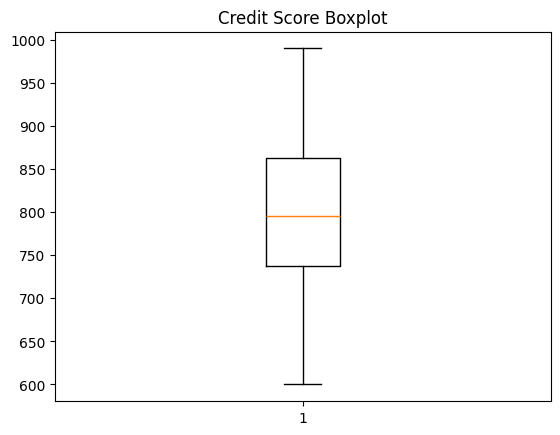

In [12]:


import matplotlib.pyplot as plt
plt.boxplot(df['Credit_Score'])
plt.title("Credit Score Boxplot")
plt.show()

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [14]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

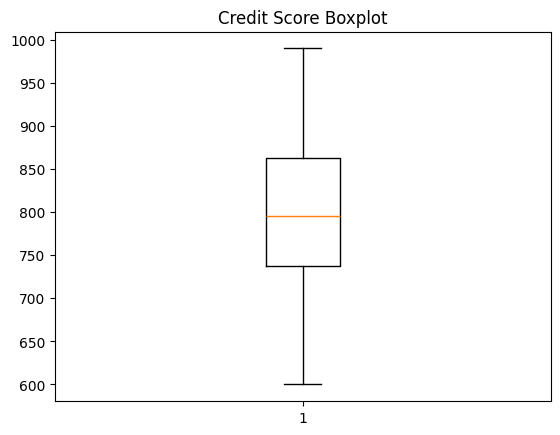

In [15]:
plt.boxplot(df['Credit_Score'])
plt.title("Credit Score Boxplot")
plt.show()

In [ ]:

df.to_csv('loan_data_cleaned.csv', index=False)

#Scaling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler